# OpenVINO lab: car detection + color classification

Flow: **Core** → **read_model** → **compile_model** → **run the models**. 

[OpenVINO 2026](https://docs.openvino.ai/2026/index.html), 

[hello-world](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/notebooks/hello-world/hello-world.ipynb)

Add **FP32**, **FP16**, **INT8** under `models/` when available.


In [1]:
import os
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import openvino as ov

from benchmark_utils import (
    benchmark_two_stage_per_device,
    classify_crops_with_labels,
    get_detection_input_hw,
    list_available_precisions,
    load_labels,
    plot_benchmark_det_cls,
    postprocess_detection,
    preprocess_detection,
    print_two_stage_benchmark_table,
    run_detection_ms,
    visualize_detection_boxes,
    visualize_labeled_boxes,
)

BASE = Path(os.environ.get("OV_DEPLOY_BASE", os.environ.get("GETI_DEPLOY_BASE", "."))).resolve()
MODELS = BASE / "models"
THRESHOLD = 0.225
DEVICE_DETECTION = "GPU"
DEVICE_CLASSIFICATION = "CPU"

print("BASE:", BASE)
print("Precision folders:", list_available_precisions(MODELS) or "(none)")


BASE: /home/ubuntu/openvino/work/geti_sdk-deployment/IndiaDevCon2026/1
Precision folders: ['FP32', 'FP16', 'INT8']


## 1. Runtime and devices


In [2]:
core = ov.Core()
print("ready")
print("devices:", core.available_devices)


ready
devices: ['CPU', 'GPU', 'NPU']


## 2. Model paths


In [3]:
available = list_available_precisions(MODELS)
if not available:
    raise FileNotFoundError(MODELS)
precision = available[0]
detection_model_path = MODELS / precision / "Detection" / "model.xml"
classification_model_path = MODELS / precision / "Classification" / "model.xml"
print("Using precision:", precision)
print(detection_model_path)
print(classification_model_path)
detection_label = load_labels(detection_model_path.parent)
detection_label = detection_label[0] if detection_label else "CAR"
classification_labels = load_labels(classification_model_path.parent)


Using precision: FP32
/home/ubuntu/openvino/work/geti_sdk-deployment/IndiaDevCon2026/1/models/FP32/Detection/model.xml
/home/ubuntu/openvino/work/geti_sdk-deployment/IndiaDevCon2026/1/models/FP32/Classification/model.xml


## 3. Compile models

In [4]:
detection_model = core.read_model(detection_model_path)
classification_model = core.read_model(classification_model_path)
compiled_detection = core.compile_model(model=detection_model, device_name=DEVICE_DETECTION)
compiled_classification = core.compile_model(model=classification_model, device_name=DEVICE_CLASSIFICATION)
# print(compiled_detection)
# print(compiled_classification)


## 4. Load image


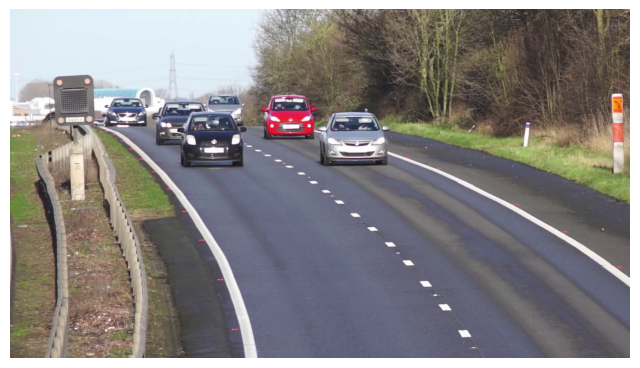

In [5]:
image_path = BASE / "media" / "sample_image-1.jpg"
if not image_path.is_file():
    raise FileNotFoundError(image_path)
image_bgr = cv2.imread(str(image_path))
assert image_bgr is not None
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

## 5. Detection: preprocess, run model, show boxes


Input tensor: (1, 3, 800, 992)
Detection time (ms): 31.47
Detections: 3


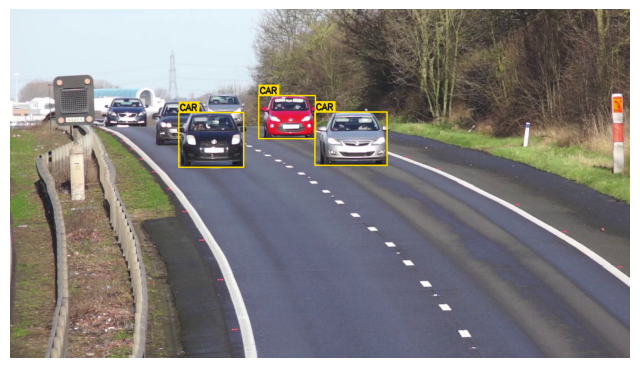

In [6]:
input_h, input_w = get_detection_input_hw(compiled_detection)
orig_h, orig_w = image_bgr.shape[:2]
input_tensor_detection = preprocess_detection(image_bgr, input_h, input_w)
print("Input tensor:", input_tensor_detection.shape)

det_ms, detection_output = run_detection_ms(compiled_detection, input_tensor_detection)
print(f"Detection time (ms): {det_ms:.2f}")

detection_boxes, _ = postprocess_detection(
    detection_output, orig_h, orig_w, input_w, input_h, THRESHOLD
)
print("Detections:", len(detection_boxes))

vis = visualize_detection_boxes(image_bgr, detection_boxes, label=detection_label)
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


## 6. Classification

Uses the **boxes from step 5**. Runs **classification** on each crop.


Classification time (ms): 16.04
CAR - Silver
CAR - Black
CAR - Red


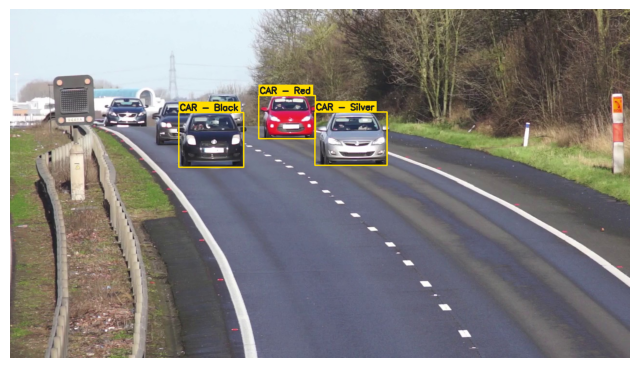

In [7]:
color_names, total_cls_ms = classify_crops_with_labels(
    compiled_classification,
    image_bgr,
    detection_boxes,
    classification_labels,
    detection_label=detection_label,
)
if len(detection_boxes):
    print(f"Classification time (ms): {total_cls_ms:.2f}")
for t in color_names:
    print(t)

final_vis = visualize_labeled_boxes(image_bgr, detection_boxes, color_names)
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(final_vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


## Try your own image


In [ ]:
# image_path = Path(r"C:/path/to/image.jpg")


## Benchmark

Precision: FP32
Classify    Det    Cls     Det_ms     Cls_ms   Total_ms Boxes
------------------------------------------------------------------------------
CPU         GPU    CPU      30.95      11.06      42.01     3
GPU         GPU    GPU      29.57       8.82      38.40     3


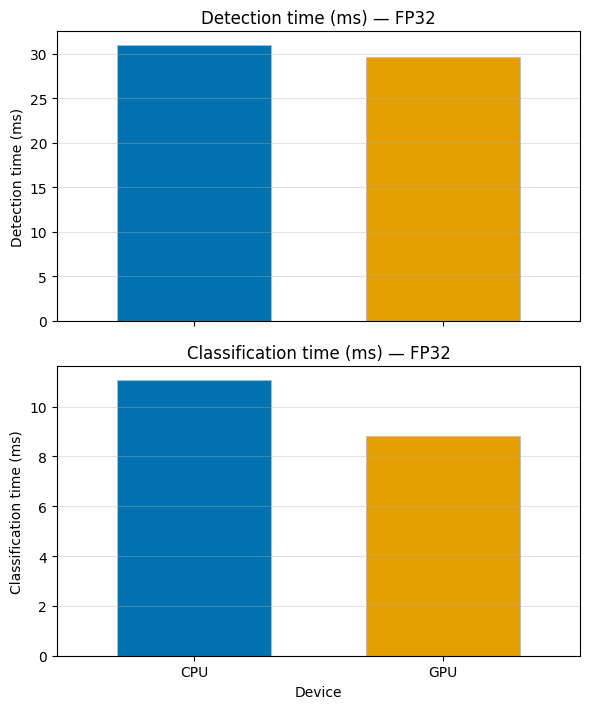

In [8]:
detection_xml = MODELS / precision / "Detection" / "model.xml"
classification_xml = MODELS / precision / "Classification" / "model.xml"
if not detection_xml.is_file() or not classification_xml.is_file():
    raise FileNotFoundError(
        f"Need Detection + Classification IRs under models/{precision}/"
    )

rows = benchmark_two_stage_per_device(
    core,
    detection_xml,
    classification_xml,
    image_bgr,
    THRESHOLD,
)
print_two_stage_benchmark_table(rows, precision)
plot_benchmark_det_cls(rows, precision)
